# EDA — LLM Agentic Legal Information Retrieval

> Inspired by [Hybrid Legal Retrieval Baseline](https://www.kaggle.com/code/ramazanturann/hybrid-legal-retrieval-baseline) by ramazanturann.

> Assisted by Claude

Swiss law is notoriously precise. Every word in every article matters. So before we throw models at this problem, let's actually understand what we're working with — the data, the quirks, and where the real difficulty lives.

This notebook covers:
- What are the queries, really?
- How many citations per query and why does it vary so wildly?
- Are we even truncating queries correctly?
- What's inside the two corpora — and are the right answers actually findable?

If this notebook helps you, please upvote — it keeps me going!

---

In [3]:
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from transformers import AutoTokenizer
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')
plt.rcParams['figure.dpi'] = 110

# Works both on Kaggle and locally
try:
    BASE = '/kaggle/input/llm-agentic-legal-information-retrieval'
    open(f'{BASE}/train.csv')
except FileNotFoundError:
    BASE = '../data'

CHAR_CUTOFF    = 2000  # baseline [:text_truncate]
EMBEDDER_LIMIT = 8192  # bge-m3 max tokens
RERANKER_LIMIT = 512   # bge-reranker-v2-m3 max tokens

In [2]:
train_df = pd.read_csv(f'{BASE}/train.csv')
val_df   = pd.read_csv(f'{BASE}/val.csv')
test_df  = pd.read_csv(f'{BASE}/test.csv')
laws_df  = pd.read_csv(f'{BASE}/laws_de.csv')
court_df = pd.read_csv(f'{BASE}/court_considerations.csv', usecols=['citation', 'text'])

laws_df['text']  = laws_df['text'].fillna('')
court_df['text'] = court_df['text'].fillna('')

print(f'train  : {len(train_df):>10,} rows — {list(train_df.columns)}')
print(f'val    : {len(val_df):>10,} rows — {list(val_df.columns)}')
print(f'test   : {len(test_df):>10,} rows — {list(test_df.columns)}')
print(f'laws   : {len(laws_df):>10,} rows — {list(laws_df.columns)}')
print(f'court  : {len(court_df):>10,} rows — {list(court_df.columns)}')

train  :      1,139 rows — ['query_id', 'query', 'gold_citations']
val    :         10 rows — ['query_id', 'query', 'gold_citations']
test   :         40 rows — ['query_id', 'query']
laws   :    175,933 rows — ['citation', 'text', 'title']
court  :  2,476,315 rows — ['citation', 'text']


## What are the queries, actually?

Before plotting anything, let's just read some examples. A lot of intuition gets built this way.

In [5]:
train_df['n_citations'] = train_df['gold_citations'].str.split(';').str.len()

print('A train query (German):')
print('─' * 60)
row = train_df[train_df['n_citations'] == 1].sample(1, random_state=7).iloc[0]
print(f"Answer : {row['gold_citations']}")
print(f"Query  : {row['query'][:400]}")

print()
print('A val query (English):')
print('─' * 60)
print(val_df['query'].iloc[0][:400])

print()
print('A complex train query (38 citations):')
print('─' * 60)
row = train_df[train_df['n_citations'] >= 38].sample(1, random_state=2).iloc[0]
print(f"Answer : {row['n_citations']} citations — {row['gold_citations'][:200]}...")
print(f"Query  : {row['query'][:400]}...")

A train query (German):
────────────────────────────────────────────────────────────
Answer : Art. 241 Abs. 3 ZGB
Query  : Beantworten Sie die folgende Frage und begründen Sie, soweit möglich unter Angabe der massge- blichen Gesetzesbestimmungen, kurz. Darf im Rahmen der Gütergemeinschaft nach geltendem Recht in einem Ehe- und Erbvertrag
Vereinbarungen hinsichtlich der Teilung des Gesamtgutes getroffen werden, die die Pflicht-
teilsansprüche der gemeinsamen Kinder beeinträchtigen?


A val query (English):
────────────────────────────────────────────────────────────
May a court lawfully order a three‑month extension of pre‑trial detention under Art. 221 Abs. 1 lit. b StPO (risk of collusion) consistent with the principle of proportionality when the accused—detained after an alleged late‑night assault and theft of a courier satchel containing, inter alia, €5,600—was remanded by an order dated 18 October 2024 for a maximum period up to 15 January 2025, the pros

A complex train query (38 

These are not keyword searches. A simple query is a focused legal question with a clear answer. A complex query is a full *Sachverhalt* — a multi-page case scenario covering inheritance, property registration, financial instruments — each aspect needing its own article of law.

Notice something important: **train queries are in German, but val and test queries are in English**. The corpus is in German (plus French and Italian for court decisions). So the actual task at eval time is cross-lingual — English queries matched against a German corpus. Train is in German, which makes it useful for learning retrieval patterns but doesn't fully represent the eval distribution.

## How many citations per query?

Let's look at the distribution. The spread here has huge implications for how we design the retrieval system.

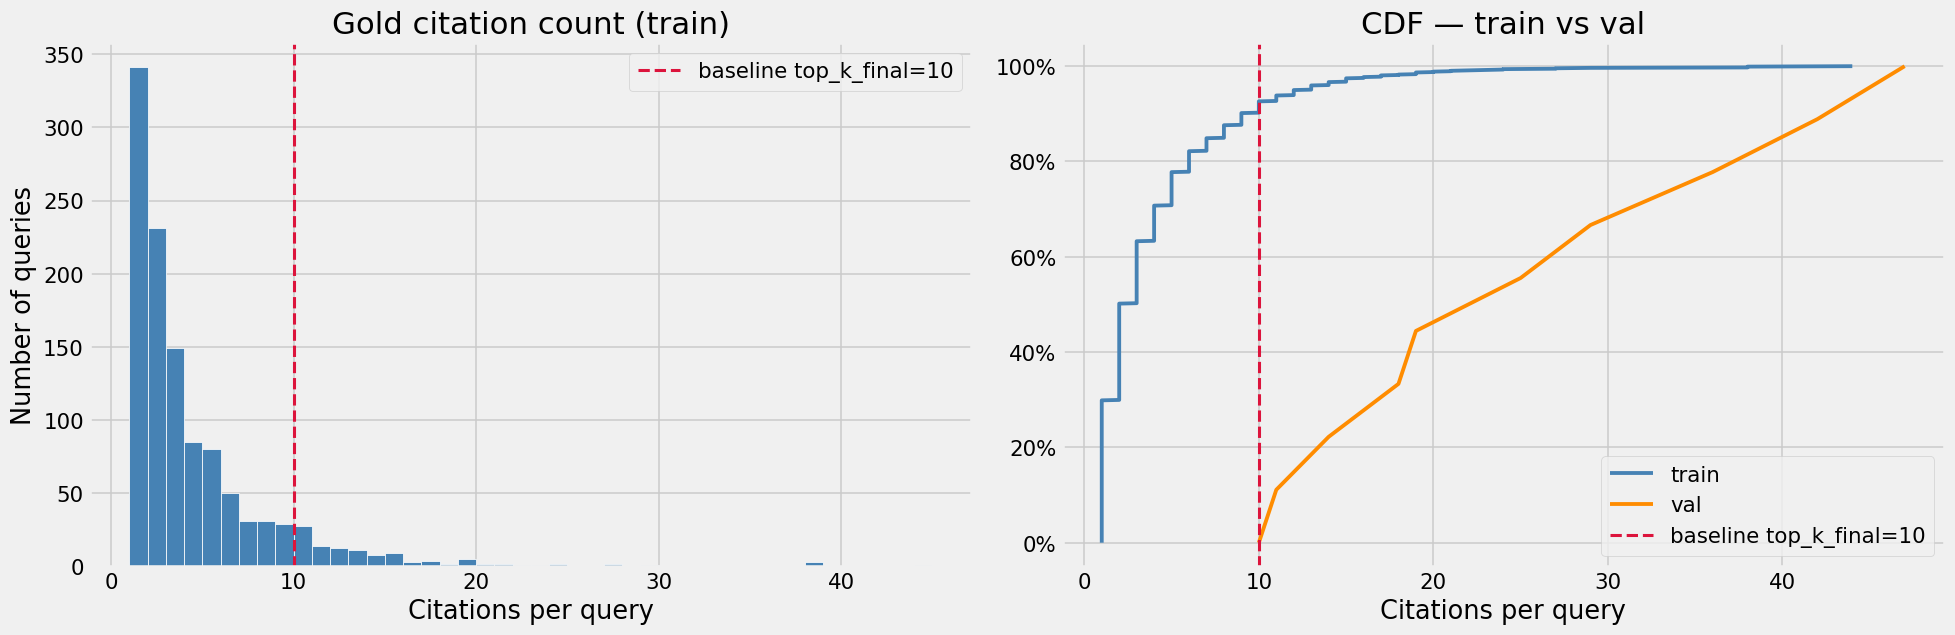

Train — median: 2, max: 44
Val   — median: 22, max: 47


In [7]:
val_df['n_citations'] = val_df['gold_citations'].str.split(';').str.len()

f, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].hist(train_df['n_citations'], bins=range(1, 46), color='steelblue', edgecolor='white')
axes[0].axvline(10, color='crimson', linestyle='--', linewidth=2, label='baseline top_k_final=10')
axes[0].set_xlabel('Citations per query')
axes[0].set_ylabel('Number of queries')
axes[0].set_title('Gold citation count (train)')
axes[0].legend()

for df, label, color in [(train_df, 'train', 'steelblue'), (val_df, 'val', 'darkorange')]:
    s = np.sort(df['n_citations'].values)
    axes[1].plot(s, np.linspace(0, 1, len(s)), label=label, linewidth=2.5, color=color)
axes[1].axvline(10, color='crimson', linestyle='--', linewidth=2, label='baseline top_k_final=10')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].set_xlabel('Citations per query')
axes[1].set_title('CDF — train vs val')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Train — median: {train_df['n_citations'].median():.0f}, max: {train_df['n_citations'].max()}")
print(f"Val   — median: {val_df['n_citations'].median():.0f}, max: {val_df['n_citations'].max()}")

The baseline caps predictions at `top_k_final=10`. For val, the median is 22 citations per query. That means the system structurally cannot achieve full recall on most val queries — the correct answers aren't even in the candidate set.

But the other direction hurts too. Returning 10 results for a 1-citation query means 9 false positives. The metric is **Macro F1** — even with perfect recall, F1 would be around 18%. You need to return roughly the *right number* of citations, not just a fixed count.

Observations:
1. The majority of train queries need only 1–5 citations (simple focused questions).
2. A long tail of complex Sachverhalt cases need 20–44 citations.
3. Val skews heavily toward the complex end — median 22 vs 2 in train.
4. A fixed top-k fails at both ends. An adaptive cutoff based on score gaps is the right approach.

## Are we even sending the full query to the model?

The baseline truncates every query at 2,000 characters before encoding. Let's see how much we're throwing away.

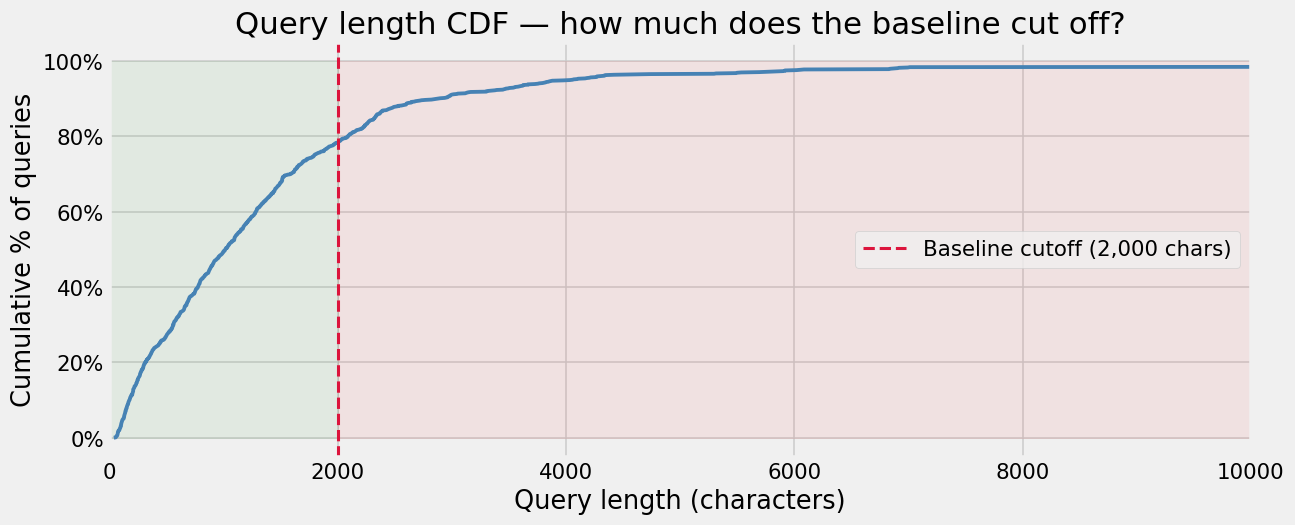

<=  1000 chars: 49.5% of queries fully captured
<=  2000 chars: 78.4% of queries fully captured
<=  3000 chars: 91.0% of queries fully captured
<=  5000 chars: 96.6% of queries fully captured

Note: 2 queries are exactly 32,767 chars (2^15−1) — CSV cell truncation artifact, not real data


In [8]:
train_df['query_len'] = train_df['query'].str.len()

lens = np.sort(train_df['query_len'].values)

f, ax = plt.subplots(figsize=(12, 5))
ax.plot(lens, np.linspace(0, 1, len(lens)), color='steelblue', linewidth=2.5)
ax.axvline(CHAR_CUTOFF, color='crimson', linestyle='--', linewidth=2,
           label=f'Baseline cutoff ({CHAR_CUTOFF:,} chars)')
ax.fill_betweenx([0, 1], 0, CHAR_CUTOFF, alpha=0.06, color='green')
ax.fill_betweenx([0, 1], CHAR_CUTOFF, 10000, alpha=0.06, color='red')
ax.set_xlim(0, 10000)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel('Query length (characters)')
ax.set_ylabel('Cumulative % of queries')
ax.set_title('Query length CDF — how much does the baseline cut off?')
ax.legend()
plt.tight_layout()
plt.show()

for c in [1000, 2000, 3000, 5000]:
    print(f'<= {c:>5} chars: {(train_df["query_len"] <= c).mean()*100:.1f}% of queries fully captured')

n_trunc = (train_df['query_len'] == 32767).sum()
if n_trunc:
    print(f'\nNote: {n_trunc} queries are exactly 32,767 chars (2^15−1) — CSV cell truncation artifact, not real data')

The baseline silently drops the tail of **22% of all queries** mid-sentence. These are precisely the complex multi-part cases where the full context matters most.

Here's the surprising part: **bge-m3 supports up to 8,192 tokens**, not 512. At a typical German characters-per-token ratio of ~3–4, that's roughly 25,000 characters of capacity. The 2,000 char cutoff uses less than 10% of what the model can actually handle.

## What's inside the two corpora?

Laws and court are very different datasets. Let's look at the text lengths and what a typical row actually contains.

In [9]:
laws_df['char_len']  = laws_df['text'].str.len()
court_df['char_len'] = court_df['text'].str.len()

print('Sample law article:')
row = laws_df.sample(1, random_state=5).iloc[0]
print(f"  citation : {row['citation']}")
print(f"  text     : {row['text']}")

print()
print('Sample court consideration:')
row = court_df[court_df['char_len'].between(200, 400)].sample(1, random_state=5).iloc[0]
print(f"  citation : {row['citation']}")
print(f"  text     : {row['text']}")

print()
print('Some very short court rows (noise):')
for t in court_df[court_df['char_len'] < 50]['text'].sample(4, random_state=1).values:
    print(f"  {repr(t)}")

Sample law article:
  citation : Art. 15a BSG
  text     : Aufsichtsbehörde ist:a. das Bundesamt für Verkehr für öffentliche Schifffahrtsunternehmen;
b. die zuständige kantonale Behörde für Schifffahrtsunternehmen ohne eidgenössische Konzession oder eidgenössische Bewilligung.

Sample court consideration:
  citation : 9C_166/2022 E. 8.1
  text     : 8.1. Nach Auffassung der Beschwerdeführerin werde ihr die für das Screening gewählte Vergleichsgruppe nicht gerecht; als Gruppenpraxis könne sie nicht einem Vergleichskollektiv gegenübergestellt werden, das aus Einzelpraxen bestehe.

Some very short court rows (noise):
  '1.3.'
  'Le recours est rejeté.'
  'Das Obergericht verzichtet auf Vernehmlassung.'
  'Il ricorso è inammissibile.'


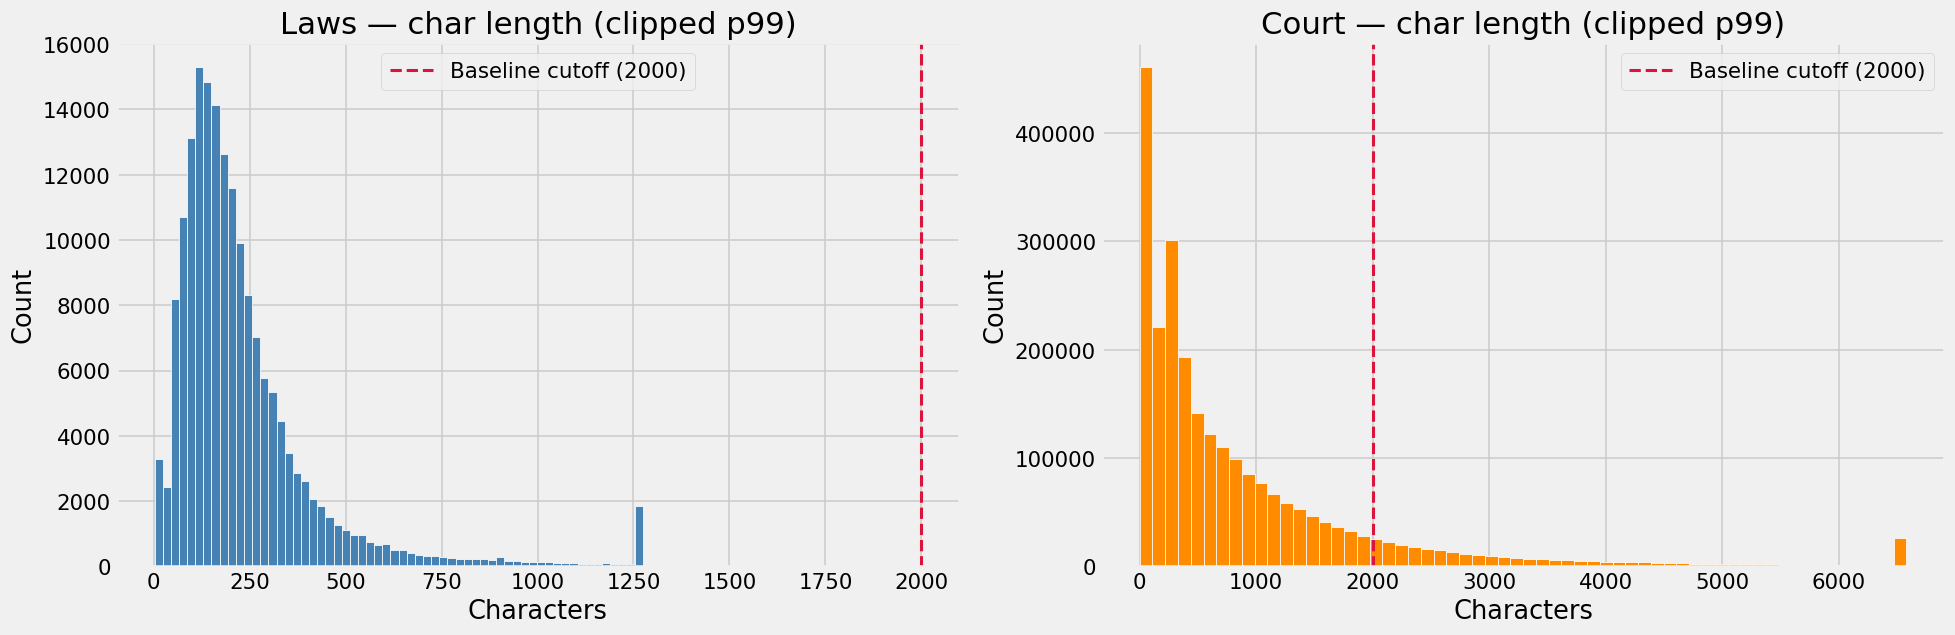

               rows    median chars    > 2000 chars   < 100 chars
─────────────────────────────────────────────────────────────────
laws        175,933             181            0.4%         18.4%
court     2,476,315             486           11.9%         17.5%


In [10]:
f, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, df, label, color in [
    (axes[0], laws_df,  'Laws',  'steelblue'),
    (axes[1], court_df, 'Court', 'darkorange')
]:
    clipped = df['char_len'].clip(upper=df['char_len'].quantile(0.99))
    ax.hist(clipped, bins=60, color=color, edgecolor='white')
    ax.axvline(CHAR_CUTOFF, color='crimson', linestyle='--', linewidth=2,
               label=f'Baseline cutoff ({CHAR_CUTOFF})')
    ax.set_xlabel('Characters')
    ax.set_ylabel('Count')
    ax.set_title(f'{label} — char length (clipped p99)')
    ax.legend()

plt.tight_layout()
plt.show()

print(f"{'':8} {'rows':>10}  {'median chars':>14}  {'> 2000 chars':>14}  {'< 100 chars':>12}")
print('─' * 65)
for df, label in [(laws_df, 'laws'), (court_df, 'court')]:
    print(f"{label:<8} {len(df):>10,}  "
          f"{df['char_len'].median():>14.0f}  "
          f"{(df['char_len'] > CHAR_CUTOFF).mean()*100:>13.1f}%  "
          f"{(df['char_len'] < 100).mean()*100:>11.1f}%")

A few things jump out:

1. Law articles are short — median around 200 characters. Most fit well within any reasonable token budget. Only a small fraction exceed 2,000 chars.
2. Court is not a collection of full decisions. Each row is one *consideration* or section of a ruling, already pre-chunked. The file is 2.5M rows not because each text is long but because there are a huge number of individual sections.
3. **17.5% of court rows are under 100 characters** — procedural one-liners: *"Il est statué sans frais"*, *"Auf die Beschwerde wird nicht eingetreten"*. Zero retrieval value. These pollute the BM25 index and waste embedding compute. Filtering them before indexing is a free improvement.
4. The court corpus is multilingual — German, French, and Italian — reflecting Switzerland's linguistic regions.

## Token lengths — what does the model actually see?

Characters are a rough proxy. Let's tokenize with bge-m3's own tokenizer to measure the true token counts.

In [11]:
tokenizer = AutoTokenizer.from_pretrained('BAAI/bge-m3')

def token_lengths(texts, batch_size=1024):
    out = []
    for i in tqdm(range(0, len(texts), batch_size), desc='tokenizing', leave=False):
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            enc = tokenizer(list(texts[i:i+batch_size]), truncation=False, add_special_tokens=True)
        out.extend(len(ids) for ids in enc['input_ids'])
    return np.array(out)

print('tokenizing laws...')
laws_df['token_len']  = token_lengths(laws_df['text'])
print('tokenizing court (may take a few minutes)...')
court_df['token_len'] = token_lengths(court_df['text'])
print('done')

tokenizing laws...


tokenizing:   0%|          | 0/172 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (8621 > 8192). Running this sequence through the model will result in indexing errors


tokenizing court (may take a few minutes)...


tokenizing:   0%|          | 0/2419 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
f, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, df, label, color in [
    (axes[0], laws_df,  'Laws',  'steelblue'),
    (axes[1], court_df, 'Court', 'darkorange')
]:
    clipped = df['token_len'].clip(upper=df['token_len'].quantile(0.99))
    ax.hist(clipped, bins=60, color=color, edgecolor='white')
    ax.axvline(RERANKER_LIMIT, color='purple', linestyle='--', linewidth=2,
               label=f'Reranker limit ({RERANKER_LIMIT} tok)')
    ax.axvline(EMBEDDER_LIMIT, color='crimson', linestyle='--', linewidth=2,
               label=f'Embedder limit ({EMBEDDER_LIMIT} tok)')
    ax.set_xlabel('Tokens')
    ax.set_ylabel('Count')
    ax.set_title(f'{label} — token length (clipped p99)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"{'':8}  {'> reranker (512)':>18}  {'> embedder (8192)':>18}  {'chars/token':>12}  {'8192 tok ≈ X chars':>20}")
print('─' * 85)
for df, label in [(laws_df, 'laws'), (court_df, 'court')]:
    ratio = (df['char_len'] / df['token_len'].clip(lower=1)).median()
    print(f"{label:<8}  "
          f"{(df['token_len'] > RERANKER_LIMIT).mean()*100:>17.1f}%  "
          f"{(df['token_len'] > EMBEDDER_LIMIT).mean()*100:>17.1f}%  "
          f"{ratio:>12.2f}  "
          f"{EMBEDDER_LIMIT * ratio:>18,.0f}")

The corpus texts are cut to 2,000 characters before embedding, even though bge-m3 can handle ~25,000 characters at a typical German chars-per-token ratio. The reranker adds a second, harder cut at 512 tokens.

Observations:
1. Laws are mostly short — the 2,000 char cutoff and the 512-token reranker limit rarely bite them.
2. Court considerations have a long tail. A meaningful share exceed 512 tokens, so the reranker silently drops the back half of those texts. With no newlines to split on cleanly, chunking court is non-trivial.
3. Removing the 2,000 char corpus truncation is a nearly free improvement for laws and a meaningful one for long court rows.

## Are the correct answers actually in the corpus?

This is the most important sanity check. A retrieval system cannot find answers that aren't there.

In [ ]:
laws_cits  = set(laws_df['citation'].dropna())
court_cits = set(court_df['citation'].dropna())
all_cits   = laws_cits | court_cits

for split, df in [('train', train_df), ('val', val_df)]:
    gold     = df['gold_citations'].str.split(';').explode().str.strip().dropna()
    in_laws  = gold.isin(laws_cits).mean()  * 100
    in_court = gold.isin(court_cits).mean() * 100
    missing  = (~gold.isin(all_cits)).mean() * 100
    print(f'{split} ({len(gold):,} total citations)')
    print(f'  in laws corpus : {in_laws:.1f}%')
    print(f'  in court corpus: {in_court:.1f}%')
    print(f'  not in corpus  : {missing:.1f}%')
    print()

# What are the missing ones?
train_gold = train_df['gold_citations'].str.split(';').explode().str.strip().dropna()
missing    = train_gold[~train_gold.isin(all_cits)]
print('Most common missing citations:')
print(missing.value_counts().head(10).to_string())

28.8% of train gold citations are completely absent from the corpus — all law articles from codes like OR (contract law), ZGB (civil code), StGB (criminal code) that were left out of `laws_de.csv`.

This sounds alarming but look at val: **0% missing**. Every single correct answer in the validation set exists in the corpus. This is almost certainly deliberate — the competition organizers curated val and test to only reference laws that are present, meaning the training missing rate is a data generation artifact, not a ceiling on your leaderboard score.

One more thing worth noting: only 1.2% of correct answers are court citations. The baseline skips dense retrieval on court entirely (it's 2.5M rows — expensive). That turns out to be nearly costless for recall.

## What we learned

| Finding | Impact | Action |
|---------|--------|--------|
| `top_k_final=10` misses most val queries — median is 22 citations | High | Raise top-k; build adaptive score-gap cutoff |
| Fixed top-k tanks F1 on simple queries (9 false positives for a 1-citation query) | High | Adaptive top-k is essential |
| Baseline truncates 22% of queries; bge-m3 supports 8,192 tokens not 512 | Medium | Raise char cutoff to at least 5,000 |
| 17.5% of court rows are procedural noise under 100 chars | Medium | Filter before indexing |
| 28.8% of train labels missing from corpus — val/test are 100% covered | Low | Expected noise; ignore for LB |
| **Cross-encoder reranker (bge-reranker-v2-m3) is nearly blind to relevant German docs when given an English query** | **Critical** | **Translate queries to German before reranking** |

The two highest-leverage improvements are both about `top_k`: raising the ceiling and making it adaptive. Everything else is secondary — except for the cross-lingual reranker issue, which is a correctness bug, not a tuning problem.

## Why does val need so many more citations?

We have gold citations for both splits, so we can map each query to SR topic categories — no LLM needed. Each citation like `Art. 45 ZGB` has an abbreviation (`ZGB`) that maps directly to one of the 10 SR topics.

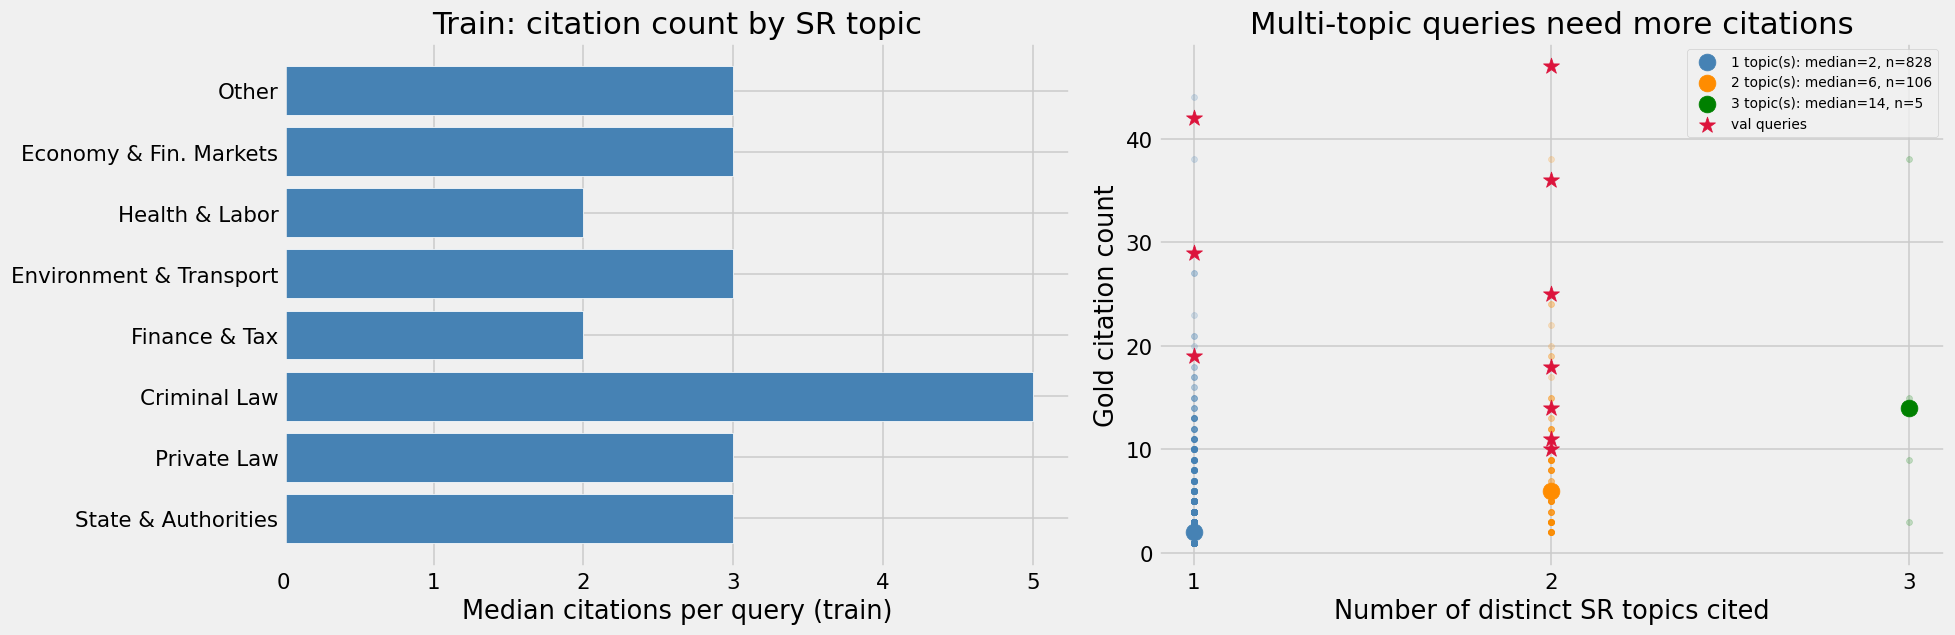

Train — citations by number of topics:
          count  median       mean  max
n_topics                               
0           200     2.0   2.630000   16
1           828     2.0   3.919082   44
2           106     6.0   7.632075   38
3             5    14.0  15.800000   38

Val n_topics distribution: [1, 1, 1, 2, 2, 2, 2, 2, 2, 2]


In [12]:
import re
from collections import defaultdict

TOPIC_MAP = {
    # Topic 1: State & Authorities
    'BV':1,'BGG':1,'VwVG':1,'DSG':1,'AIG':1,'VGG':1,
    # Topic 2: Private Law
    'ZGB':2,'OR':2,'ZPO':2,'GBV':2,'IPRG':2,'URG':2,'SchKG':2,'VVG':2,'MSchG':2,'UWG':2,'KGTG':2,
    # Topic 3: Criminal Law
    'StGB':3,'StPO':3,'JStG':3,'JStPO':3,'IRSG':3,
    # Topic 6: Finance & Tax
    'DBG':6,'StHG':6,'VStG':6,'MWSTG':6,'VStV':6,
    # Topic 7: Environment & Transport
    'SVG':7,'EBG':7,'RPG':7,'RPV':7,'USG':7,'GSchG':7,'NHG':7,'LSV':7,
    # Topic 8: Health & Labor
    'KVG':8,'UVG':8,'UVV':8,'ATSG':8,'AHVG':8,'IVG':8,'BVG':8,'ArG':8,'BEG':8,'FZG':8,
    # Topic 9: Economy & Financial Markets
    'FIDLEG':9,'FINMAG':9,'FINIG':9,'FIDLEV':9,'BEHG':9,'KAG':9,'BankG':9,
}
TOPIC_NAMES = {
    1:'State & Authorities', 2:'Private Law', 3:'Criminal Law',
    6:'Finance & Tax', 7:'Environment & Transport',
    8:'Health & Labor', 9:'Economy & Fin. Markets', 99:'Other',
}

def get_topics(citations_str):
    topics = set()
    for c in str(citations_str).split(';'):
        m = re.search(r'\b([A-ZÜÄÖ]{2,}(?:[a-zA-Züäö]*[A-ZÜÄÖ])?)\s*$', c.strip())
        if m:
            topics.add(TOPIC_MAP.get(m.group(1), 99))
    return topics

train_df['topics']   = train_df['gold_citations'].apply(get_topics)
train_df['n_topics'] = train_df['topics'].apply(len)
val_df['topics']     = val_df['gold_citations'].apply(get_topics)
val_df['n_topics']   = val_df['topics'].apply(len)

# Per-topic stats from train
topic_stats = defaultdict(list)
for _, row in train_df.iterrows():
    for t in row['topics']:
        topic_stats[t].append(row['n_citations'])

# Plot 1: citations per topic (train) + val overlay
topic_ids   = sorted(topic_stats.keys())
topic_labels = [TOPIC_NAMES[t] for t in topic_ids]
train_medians = [np.median(topic_stats[t]) for t in topic_ids]
val_counts    = {t: [] for t in topic_ids}
for _, row in val_df.iterrows():
    for t in row['topics']:
        if t in val_counts:
            val_counts[t].append(row['n_citations'])

f, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: train median per topic
axes[0].barh(topic_labels, train_medians, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Median citations per query (train)')
axes[0].set_title('Train: citation count by SR topic')

# Right: n_topics vs n_citations
for n, color in [(1,'steelblue'), (2,'darkorange'), (3,'green')]:
    sub = train_df[train_df['n_topics'] == n]
    if len(sub):
        axes[1].scatter([n]*len(sub), sub['n_citations'],
                        alpha=0.2, s=15, color=color)
        axes[1].scatter([n], [sub['n_citations'].median()],
                        s=120, color=color, zorder=5,
                        label=f'{n} topic(s): median={sub["n_citations"].median():.0f}, n={len(sub)}')

# Val points
for _, row in val_df.iterrows():
    axes[1].scatter([row['n_topics']], [row['n_citations']],
                    s=120, color='crimson', marker='*', zorder=6)
axes[1].scatter([], [], s=120, color='crimson', marker='*', label='val queries')
axes[1].set_xlabel('Number of distinct SR topics cited')
axes[1].set_ylabel('Gold citation count')
axes[1].set_title('Multi-topic queries need more citations')
axes[1].set_xticks([1, 2, 3])
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("Train — citations by number of topics:")
print(train_df.groupby('n_topics')['n_citations'].agg(['count','median','mean','max']).to_string())
print(f"\nVal n_topics distribution: {sorted(val_df['n_topics'].tolist())}")

The topic itself doesn't explain the gap — val queries hit the same topics as train (Private Law, State & Authorities, Health & Labor). Train median for these is 2–3 citations.

The real driver is **multi-topic queries**. In train, queries spanning 2 SR topics need a median of 6 citations; 3 topics need 14. Val has 7 out of 10 queries spanning 2 topics — but even that only gets us to a median of 6 in train, far below val's 22.

Observations:
1. **Same topics, very different citation counts.** Val doesn't pick harder topic areas — it picks the same ones but asks comprehensive questions that touch every relevant article.
2. **Multi-topic is the strongest structural signal.** A query spanning 2 law areas needs roughly 3× more citations than a single-topic query. 70% of val queries are multi-topic vs only 9% of train.
3. **Within multi-topic, val is still an outlier.** Train's 2-topic max is 38; val queries cluster at 10–47. Val scenarios are exhaustive by design.
4. **Implication for adaptive top-k:** detecting multi-topic at query time (before retrieval) could give a rough prior. But the score gap from the reranker is still the cleanest signal — it adapts to the actual retrieved content, not just the query structure.

## Is query complexity hiding citations?

Val queries need 10–47 citations while train queries need 1–44 (median 2). The obvious explanation is that val queries are just more complex. Let's check if the complexity actually justifies the gap.

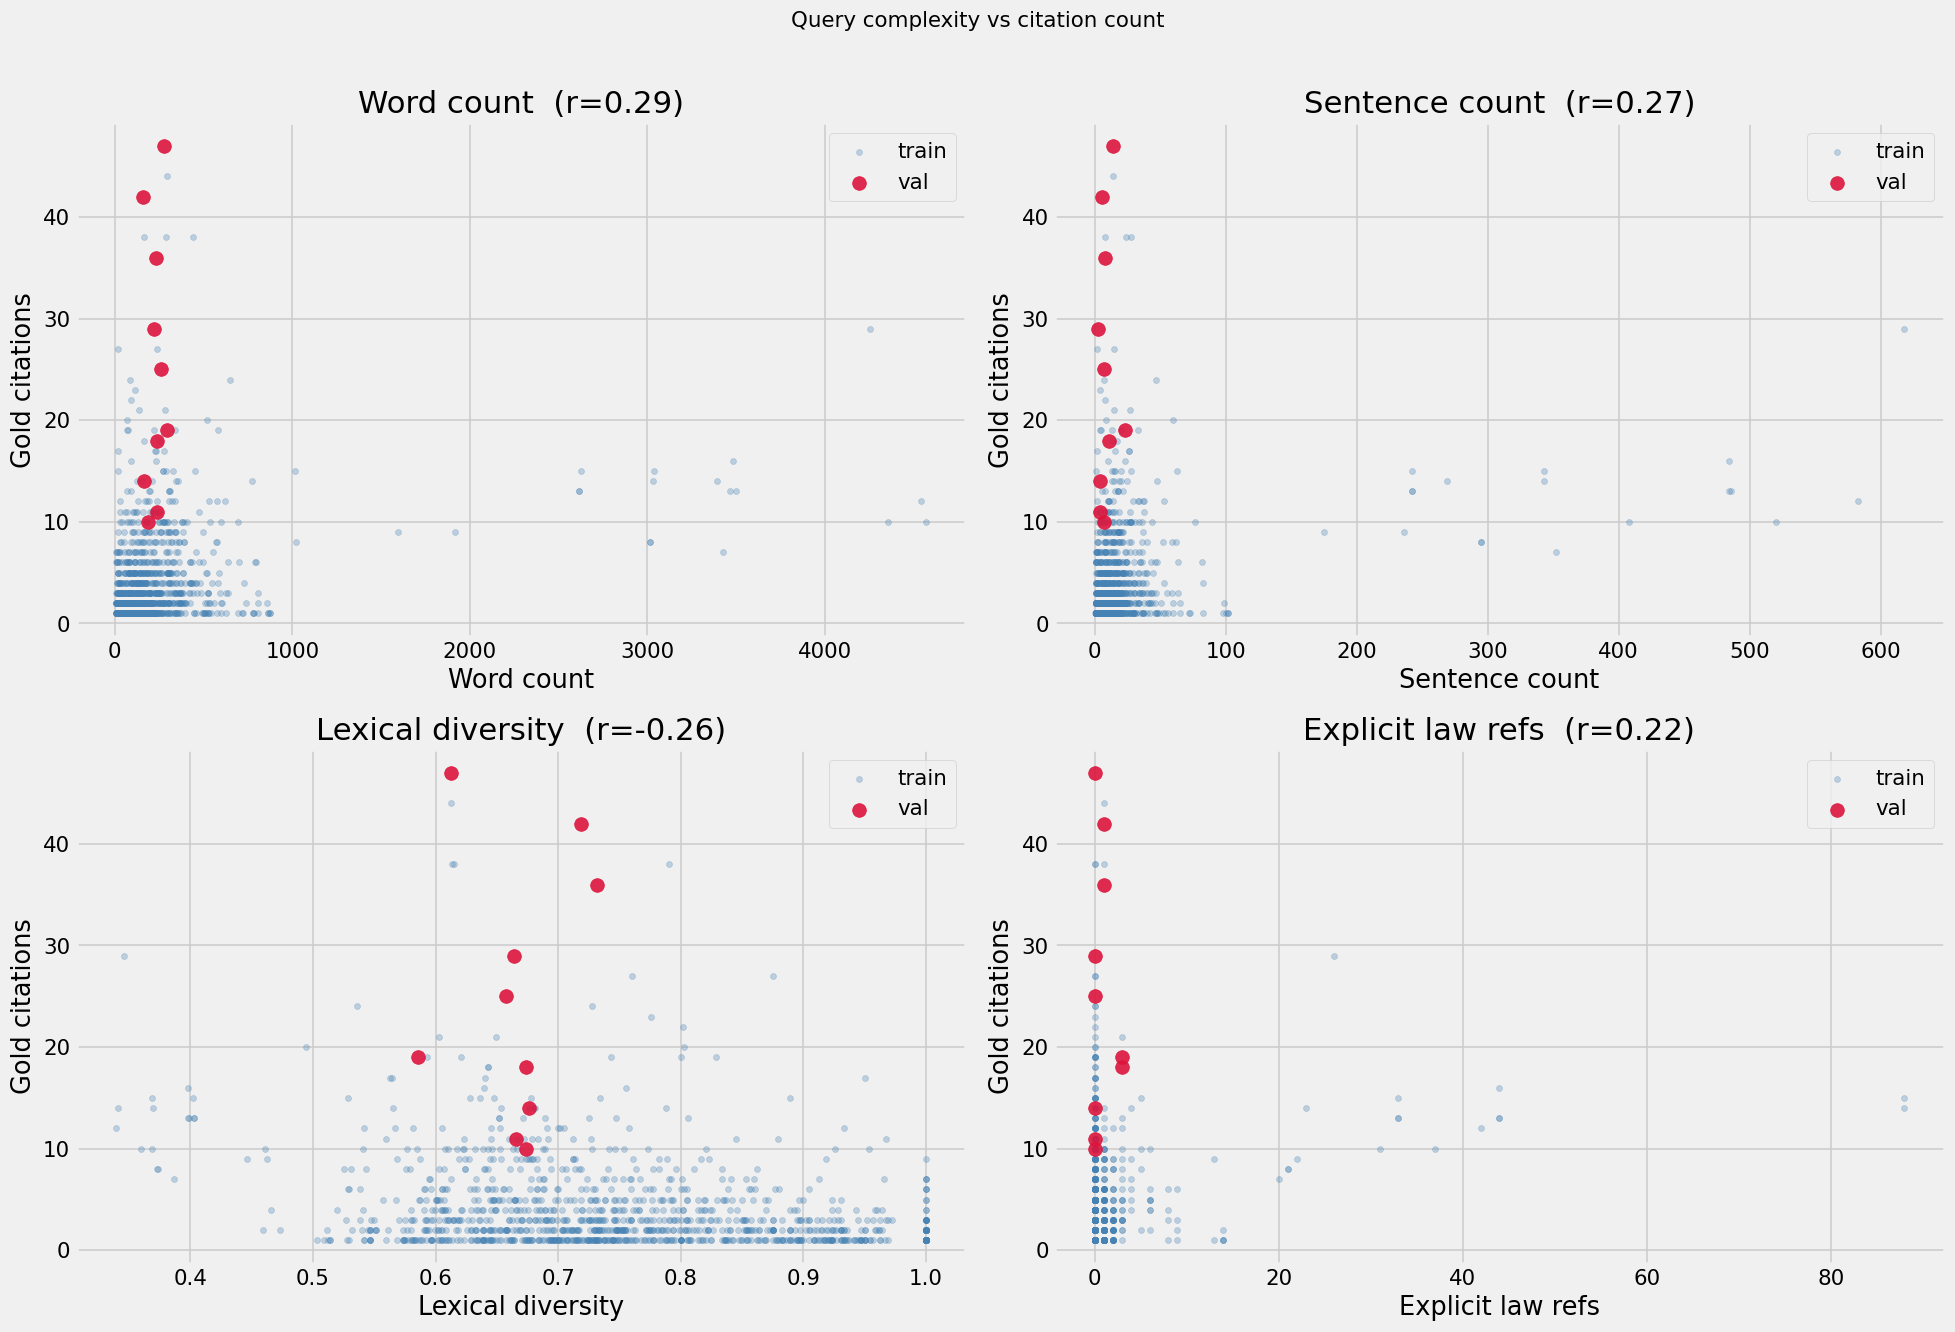

In [37]:
import re

def complexity_features(df):
    df = df.copy()
    df['n_citations'] = df['gold_citations'].str.split(';').str.len()
    df['word_count']  = df['query'].str.split().str.len()
    df['sent_count']  = df['query'].str.count(r'[.!?]')
    df['lexical_div'] = df['query'].apply(
        lambda q: len(set(str(q).lower().split())) / max(len(str(q).split()), 1)
    )
    df['law_refs']    = df['query'].str.count(r'Art\.\s*\d+')
    return df

train_df = complexity_features(train_df)
val_df   = complexity_features(val_df)

features = ['word_count', 'sent_count', 'lexical_div', 'law_refs']
labels   = ['Word count', 'Sentence count', 'Lexical diversity', 'Explicit law refs']

f, axes = plt.subplots(2, 2, figsize=(18, 12))

for ax, feat, label in zip(axes.flat, features, labels):
    ax.scatter(train_df[feat], train_df['n_citations'],
               alpha=0.3, s=15, color='steelblue', label='train')
    ax.scatter(val_df[feat],   val_df['n_citations'],
               alpha=0.9, s=80, color='crimson',   label='val', zorder=5)
    r = train_df[feat].corr(train_df['n_citations'])
    ax.set_xlabel(label)
    ax.set_ylabel('Gold citations')
    ax.set_title(f'{label}  (r={r:.2f})')
    ax.legend()

plt.suptitle('Query complexity vs citation count', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

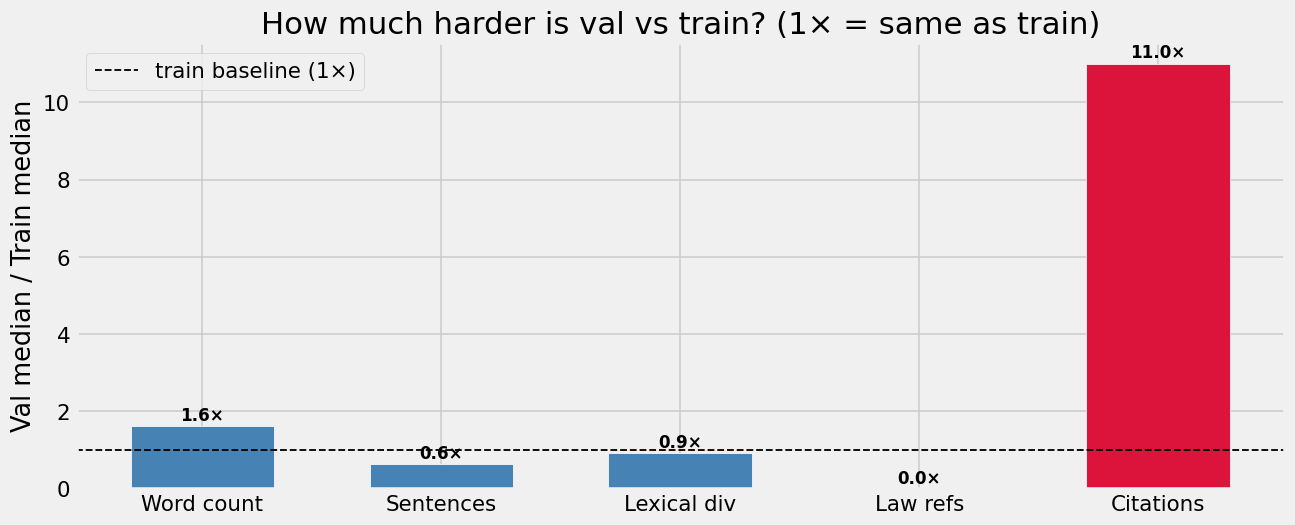

Train medians: {'Word count': '145.0', 'Sentences': '11.0', 'Lexical div': '0.7', 'Law refs': '0.0', 'Citations': '2.0'}
Val medians  : {'Word count': '233.5', 'Sentences': '7.0', 'Lexical div': '0.7', 'Law refs': '0.0', 'Citations': '22.0'}


In [38]:
fig, ax = plt.subplots(figsize=(12, 5))

metrics = ['word_count', 'sent_count', 'lexical_div', 'law_refs', 'n_citations']
mlabels = ['Word count', 'Sentences', 'Lexical div', 'Law refs', 'Citations']

train_med = [train_df[m].median() for m in metrics]
val_med   = [val_df[m].median()   for m in metrics]

# Normalise to train median so everything is on same scale
ratio = [v / t if t > 0 else 0 for v, t in zip(val_med, train_med)]

x = np.arange(len(metrics))
bars = ax.bar(x, ratio, color=['steelblue']*4 + ['crimson'], edgecolor='white', width=0.6)
ax.axhline(1.0, color='black', linewidth=1.2, linestyle='--', label='train baseline (1×)')
for bar, r in zip(bars, ratio):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{r:.1f}×', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(mlabels)
ax.set_ylabel('Val median / Train median')
ax.set_title('How much harder is val vs train? (1× = same as train)')
ax.legend()
plt.tight_layout()
plt.show()

print("Train medians:", {l: f'{train_df[m].median():.1f}' for l, m in zip(mlabels, metrics)})
print("Val medians  :", {l: f'{val_df[m].median():.1f}'   for l, m in zip(mlabels, metrics)})

Val queries are about **1.6× longer** than the typical train query. But they require **11× more citations**. Lexical diversity and explicit law references are essentially identical between the two splits.

The complexity doesn't come close to explaining the citation gap. A few conclusions:

1. **Val was deliberately curated to be citation-heavy** — this is a benchmark designed to stress-test recall, not a random sample of the full distribution.
2. **The training set is not hiding citations** — the queries genuinely need fewer. Train queries are mostly focused one-issue questions; val queries are full multi-issue *Sachverhalte*.
3. **Complexity is a weak predictor of citation count** (r≈0.28). Query length alone won't give you a reliable adaptive top-k. You need the model's own confidence (score gap) to decide where to cut.
4. **The real distribution shift is query type, not query length.** Val queries ask about scenarios that span multiple areas of law simultaneously. Training on simple German queries and evaluating on complex English multi-issue scenarios is a hard domain shift.

## Cross-lingual mismatch: the reranker is nearly blind to relevant German docs

Val and test queries are in English. The corpus is in German. The pipeline uses `bge-reranker-v2-m3` as a cross-encoder reranker — let's measure whether language mismatch actually hurts.

A cross-encoder sees query and document **concatenated as raw tokens**:

```
[CLS] What is pre-trial detention? [SEP] Untersuchungshaft darf nur... [SEP]
```

Relevance is scored by attending *across* query tokens to document tokens. "detention" and "Untersuchungshaft" are completely different token IDs — no surface overlap. A bi-encoder never has this problem because it compresses each text into a vector independently; language is gone before comparison. Here, language stays present as raw tokens throughout.

We test three conditions on the same documents, varying only the query language:
- **EN-query / DE-doc** — the actual pipeline
- **DE-query / DE-doc** — oracle (same language)
- **EN-query / EN-doc** — monolingual control

In [ ]:
import torch
from transformers import AutoModelForSequenceClassification

RERANKER_MODEL = 'BAAI/bge-reranker-v2-m3'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

reranker_tokenizer = AutoTokenizer.from_pretrained(RERANKER_MODEL)
reranker_model = AutoModelForSequenceClassification.from_pretrained(RERANKER_MODEL)
reranker_model.eval().to(DEVICE)

@torch.no_grad()
def rerank_score(query: str, documents: list[str]) -> np.ndarray:
    pairs = [[query, doc] for doc in documents]
    inputs = reranker_tokenizer(pairs, padding=True, truncation=True,
                                max_length=512, return_tensors='pt').to(DEVICE)
    logits = reranker_model(**inputs).logits.squeeze(-1)
    return torch.sigmoid(logits).cpu().numpy()

print(f'Reranker loaded on {DEVICE}.')

In [ ]:
query_en = "What are the conditions for ordering pre-trial detention under Swiss law?"
query_de = "Was sind die Voraussetzungen für die Anordnung von Untersuchungshaft nach Schweizer Recht?"

docs_de = [
    "Untersuchungshaft darf nur angeordnet werden, wenn die beschuldigte Person eines Verbrechens oder Vergehens dringend verdächtig ist und ernsthafte Bedenken bestehen, dass sie sich durch Flucht der Strafverfolgung entzieht, oder die Gefahr besteht, dass sie Personen beeinflusst oder Beweise vernichtet.",
    "Die Haftdauer darf die mutmassliche Dauer der zu erwartenden Freiheitsstrafe nicht übersteigen.",
    "Die beschuldigte Person hat das Recht, einen Verteidiger beizuziehen.",
    "Das Gericht kann eine Busse bis zu 1000 Franken verhängen.",
    "Der Eigentümer einer Sache kann diese von jedem, der sie ihm vorenthält, herausverlangen.",
    "Lorem ipsum dolor sit amet, consectetur adipiscing elit.",
]
docs_en = [
    "Pre-trial detention may only be ordered if the accused is strongly suspected of a crime and there are serious concerns they will flee prosecution, or there is a risk they will influence persons or destroy evidence.",
    "The duration of detention may not exceed the expected length of the anticipated custodial sentence.",
    "The accused has the right to engage a defense counsel.",
    "The court may impose a fine of up to 1,000 francs.",
    "The owner of a thing may reclaim it from anyone who withholds it.",
    "Lorem ipsum dolor sit amet, consectetur adipiscing elit.",
]
doc_labels = [
    'Exact match (detention conditions)',
    'Partial (detention duration)',
    'Related (right to counsel)',
    'Same domain, different topic (fine)',
    'Different domain (property law)',
    'Gibberish',
]

scores_en_de = rerank_score(query_en, docs_de)   # actual pipeline
scores_de_de = rerank_score(query_de, docs_de)   # oracle
scores_en_en = rerank_score(query_en, docs_en)   # monolingual control

comparison = pd.DataFrame({
    'document':          doc_labels,
    'EN-query/DE-doc':   scores_en_de,
    'DE-query/DE-doc':   scores_de_de,
    'EN-query/EN-doc':   scores_en_en,
})
comparison['language_penalty'] = comparison['DE-query/DE-doc'] - comparison['EN-query/DE-doc']

pd.set_option('display.float_format', '{:.4f}'.format)
print(comparison.to_string(index=False))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

x = np.arange(len(doc_labels))
w = 0.28

axes[0].barh(x + w, comparison['EN-query/EN-doc'], w, label='EN-query/EN-doc (control)',  color='steelblue')
axes[0].barh(x,     comparison['DE-query/DE-doc'], w, label='DE-query/DE-doc (oracle)',   color='green')
axes[0].barh(x - w, comparison['EN-query/DE-doc'], w, label='EN-query/DE-doc (pipeline)', color='tomato')
axes[0].set_yticks(x)
axes[0].set_yticklabels(doc_labels, fontsize=9)
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Reranker score (sigmoid)')
axes[0].set_title('Score by language pair — all relevance tiers')
axes[0].legend(fontsize=9)

penalty = comparison['language_penalty']
colors_p = ['green' if p >= 0 else 'tomato' for p in penalty]
axes[1].barh(doc_labels[::-1], penalty[::-1], color=colors_p[::-1], edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Score gain when query is in German\n(DE-query/DE-doc  −  EN-query/DE-doc)')
axes[1].set_title('Language penalty per document')

plt.suptitle('Cross-lingual mismatch diagnostic — bge-reranker-v2-m3', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Penalty on exact-match doc:  {penalty.iloc[0]:+.4f}")
print(f"Penalty on gibberish:        {penalty.iloc[-1]:+.4f}")
print(f"Ratio:                       {penalty.iloc[0] / max(abs(penalty.iloc[-1]), 1e-9):.0f}×")

The exact-match document scores **0.022** in the pipeline — indistinguishable from gibberish (≈0.000016). With a German query the same model scores it **0.787**, nearly identical to the monolingual English control (0.841). The model has the knowledge; it just can't bridge the language gap at inference time.

The key detail is where the penalty lands: **irrelevant documents are unaffected**. Their scores are near-zero in all three conditions, and the language penalty is effectively zero. The suppression is concentrated entirely on the semantically relevant pair — the model doesn't score everything lower uniformly, it specifically kills the signal you need.

**Fix: translate queries to German before reranking.** The bi-encoder retrieval step uses cross-lingual embeddings and handles English queries fine — only the reranker needs the query in German.